## Importing Libraries

In [1]:
import re # Regular Expression used for removing special characters
import nltk # Natural Language Toolkit used for tokenization
import string # String used for removing punctuation
import pandas as pd # Pandas used for data cleaning
import numpy as np # Numpy used for mathematical operations
import matplotlib.pyplot as plt # Matplotlib used for data visualization
import seaborn as sns # Seaborn used for data visualization
from nltk.corpus import stopwords # Stopwords used for removing stopwords
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF used for feature extraction
from sklearn.model_selection import train_test_split # Used for splitting the data into training and testing sets
from sklearn.linear_model import LogisticRegression # Used for training the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Used for evaluating the performance of the model

In [2]:
dataset = pd.read_csv('Twitter.csv')

In [3]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [4]:
dataset.isnull().sum()

Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          24783 non-null  int64
 1   count               24783 non-null  int64
 2   hate_speech         24783 non-null  int64
 3   offensive_language  24783 non-null  int64
 4   neither             24783 non-null  int64
 5   class               24783 non-null  int64
 6   tweet               24783 non-null  str  
dtypes: int64(6), str(1)
memory usage: 3.3 MB


In [6]:
dataset.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [7]:
dataset["labels"] = dataset["class"].map({0: "hate_speech", 1: "offensive_language", 2: "normal"})

In [8]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,normal
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,offensive_language
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,offensive_language
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,offensive_language
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,offensive_language
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,offensive_language
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an...",normal
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...,offensive_language
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies,offensive_language


In [9]:
data = dataset[["tweet", "labels"]]

In [10]:
data

,tweet,labels
0,!!! RT @mayasolovely: As a woman you shouldn't...,normal
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,offensive_language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,offensive_language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,offensive_language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,offensive_language
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,offensive_language
24779,"you've gone and broke the wrong heart baby, an...",normal
24780,young buck wanna eat!!.. dat nigguh like I ain...,offensive_language
24781,youu got wild bitches tellin you lies,offensive_language


### Importing Stopwords and stemmer from NLTK

In [11]:
stopwords = set(stopwords.words('english')) # Remove common words that usually don't add much meaning.

stemmer = nltk.SnowballStemmer("english")  # Convert words to their root form.

### Data Cleaning using Regular Expressions

In [12]:
def clean_text(text): # for data cleaning and preprocessing
    if pd.isna(text):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"<.*?>+", "", text)
    text = re.sub(r"[%s]" % re.escape(string.punctuation), "", text)
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\w*\d\w*", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove extra whitespace
    text = ' '.join(text.split())

    # stemming the text
    text = [stemmer.stem(text) for word in text.split(" ")]
    text = " ".join(text)
    
    return text

In [13]:
data["tweet"] = data["tweet"].apply(clean_text)

In [14]:
data["tweet"].tail()

24778    yous a muthafin lie right his tl is trash now ...
24779    youve gone and broke the wrong heart baby and ...
24780    young buck wanna eat dat nigguh like i aint fu...
24781    youu got wild bitches tellin you li youu got w...
24782    ruffled ntac eileen dahlia beautiful color com...
Name: tweet, dtype: str

In [15]:
X = np.array(data["tweet"])
Y = np.array(data["labels"])

In [16]:
X

array(['rt as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out rt as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out rt as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out rt as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out rt as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out rt as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out rt as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out rt as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out rt as a woman you shouldnt complain about cleaning up your house amp as 

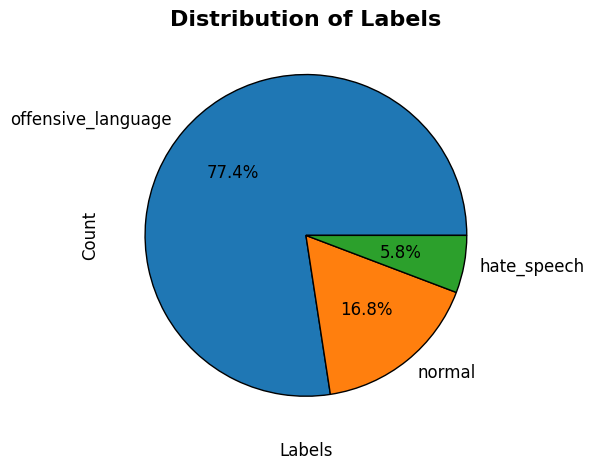

In [17]:
data["labels"].value_counts().plot(kind="pie", fontsize=12, rot=90, grid=True, autopct='%1.1f%%', wedgeprops={"linewidth": 1, "edgecolor": "black"})
plt.xlabel("Labels", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Labels", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Text to Vector Conversion using TF-IDF

In [18]:
tf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X = tf.fit_transform(X)

### Splitting the dataset into training and testing sets

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [20]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 157313 stored elements and shape (19826, 10000)>

### Building the Logistic Regression model

In [21]:
model = LogisticRegression()

model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
Y_pred = model.predict(X_test)

### Calculating the accuracy of the model

In [23]:
Accuracy = accuracy_score(Y_test, Y_pred)

print("Accuracy:", Accuracy * 100)

Accuracy: 89.04579382691144


### Classification Report of the model

In [24]:
c_report = classification_report(Y_test, Y_pred)

print(c_report)

                    precision    recall  f1-score   support

       hate_speech       0.48      0.13      0.20       286
            normal       0.85      0.81      0.83       833
offensive_language       0.91      0.97      0.93      3838

          accuracy                           0.89      4957
         macro avg       0.75      0.63      0.65      4957
      weighted avg       0.87      0.89      0.87      4957



### Confusion Matrix of the model

In [25]:
cm = confusion_matrix(Y_test, Y_pred)

print(cm)

[[  36   21  229]
 [   4  671  158]
 [  35   96 3707]]


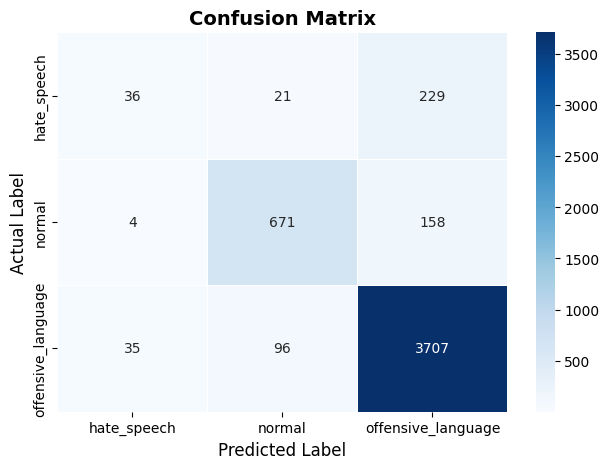

In [26]:
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", linewidths=0.5,
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.show()

In [33]:
test_texts = [
        "I love this beautiful day!",
        "You are such an idiot and should be fucked",
        "Great weather today, perfect for a walk",
        "I hate all these stupid people",
        "Have a wonderful day everyone!"
    ]

In [34]:
for text in test_texts:
    clean = clean_text(text)
    vec = tf.transform([clean])
    pred = model.predict(vec)
    prob = model.predict_proba(vec)[0]

    con = max(prob)
    confidence = round(con * 100, 2)

    print(f"Text: {text}\nPredicted Label: {pred[0]}")
    print("Confidence:", confidence)
    print("\n")


Text: I love this beautiful day!
Predicted Label: normal
Confidence: 48.36


Text: You are such an idiot and should be fucked
Predicted Label: offensive_language
Confidence: 73.85


Text: Great weather today, perfect for a walk
Predicted Label: normal
Confidence: 86.41


Text: I hate all these stupid people
Predicted Label: hate_speech
Confidence: 64.92


Text: Have a wonderful day everyone!
Predicted Label: normal
Confidence: 59.07




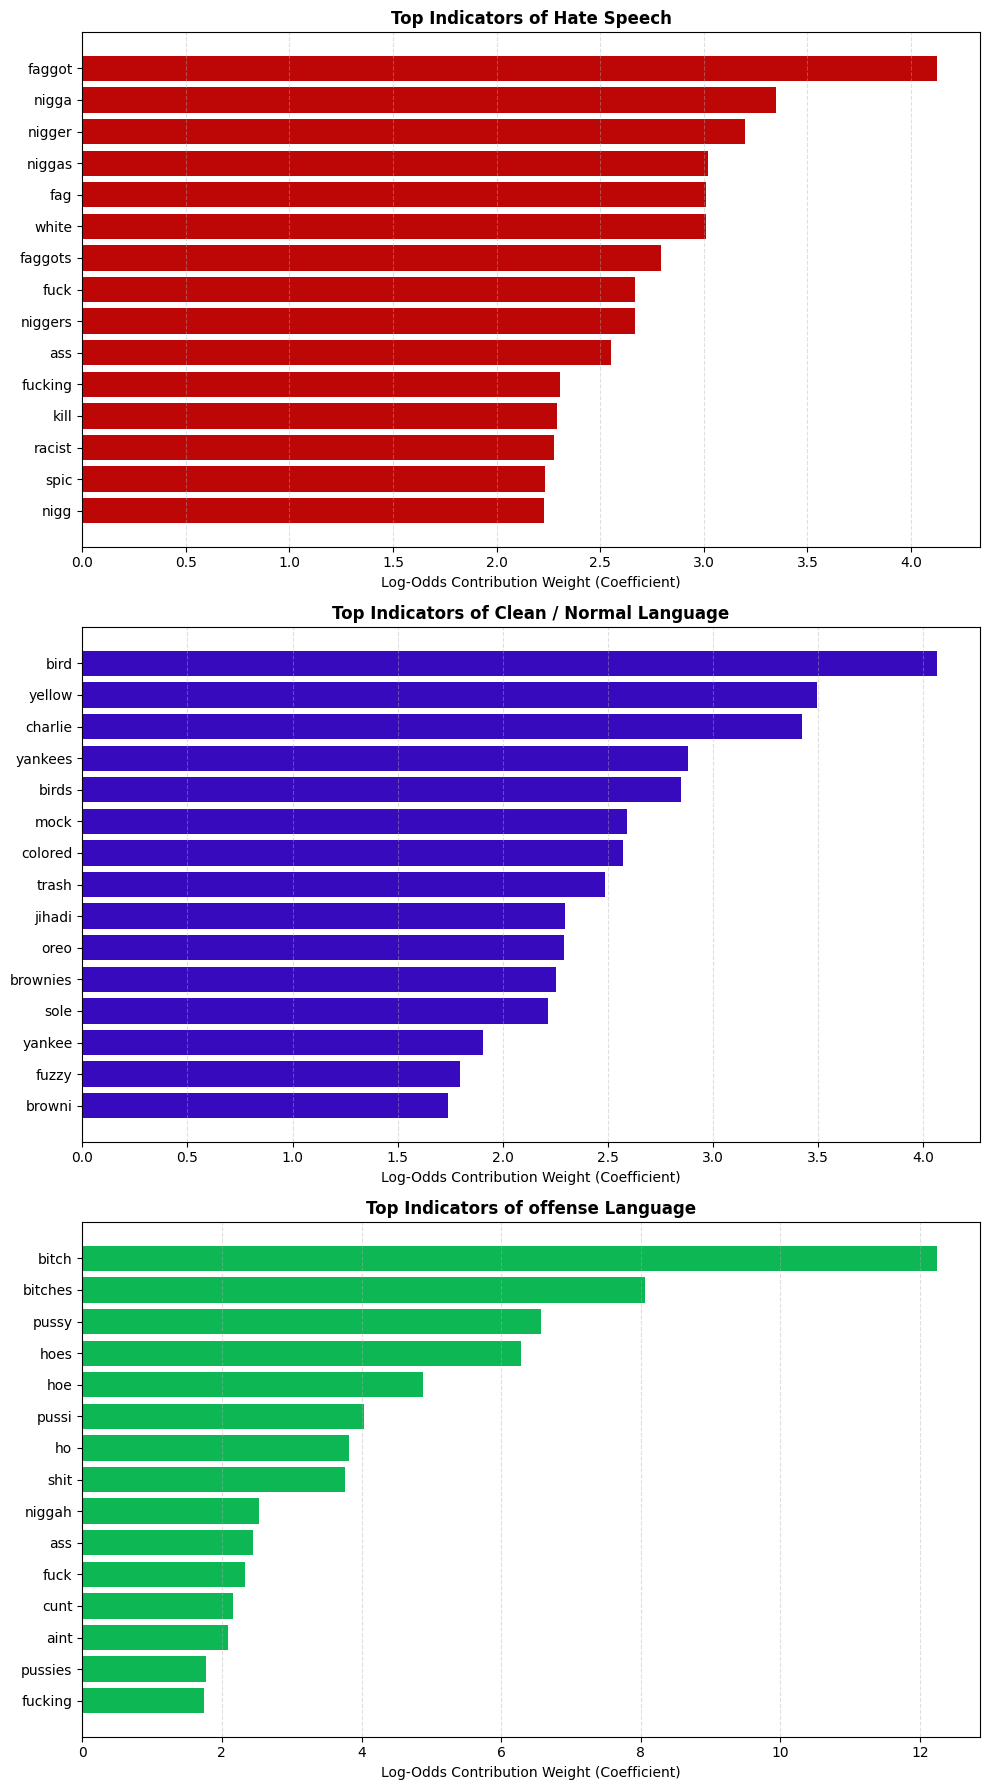

In [32]:
feature_names = tf.get_feature_names_out()
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

class_info = [
    ('hate_speech', 0, "#bd0707", 'Top Indicators of Hate Speech'),
    ('offensive_language', 1, "#370abe", 'Top Indicators of Clean / Normal Language'),
    ('normal', 2, "#0db754", 'Top Indicators of offense Language')
]

for class_label, idx, bar_color, title_text in class_info:
    # Find coefficients for the current class
    class_coef = model.coef_[idx]
    top_indices = np.argsort(class_coef)[::-1][:15]
    
    top_tokens = [feature_names[i] for i in top_indices]
    top_weights = [class_coef[i] for i in top_indices]
    
    # Plot horizontal bar
    axes[idx].barh(top_tokens[::-1], top_weights[::-1], color=bar_color)
    axes[idx].set_title(title_text, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Log-Odds Contribution Weight (Coefficient)', fontsize=10)
    axes[idx].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()